# Week 1 – Thermal Physics Foundation

## Objective

The objective of this notebook is to understand the physical principles behind thermal remote sensing using the Landsat 8/9 Thermal Infrared Sensor (TIRS).

The notebook demonstrates the complete radiometric conversion pipeline:

> Digital Number (DN) -> Spectral Radiance -> Brightness Temperature

These preprocessing steps are essential before thermal satellite imagery can be used for analysis or machine learning applications.

The notebook also validates the mathematical derivation using a real Landsat 8 Level-1 scene.

---

## 1. Introduction to Thermal Remote Sensing

Remote sensing is the science of observing the Earth's surface without direct physical contact. Optical satellites record sunlight reflected from the Earth's surface, whereas thermal satellites measure infrared radiation naturally emitted by objects.

Every object whose temperature is above absolute zero (0 K or −273.15°C) continuously emits electromagnetic radiation. The amount of radiation emitted depends primarily on the object's temperature and physical properties.

The Landsat Thermal Infrared Sensor (TIRS) measures this emitted thermal radiation rather than measuring temperature directly.

---

## 2. Thermal Radiation

During daytime, solar radiation heats the Earth's surface.

After absorbing this energy, the surface emits thermal infrared radiation according to its temperature.

The emitted infrared energy travels through the atmosphere and reaches the satellite sensor.

The sensor converts the received infrared energy into an electrical signal, which is then digitized into Digital Numbers (DN).

Therefore, every pixel stored inside a thermal image initially represents only a sensor response rather than a physical temperature.

The measurement process can be summarized as:

```

Sun
↓
Earth absorbs solar energy
↓
Surface temperature increases
↓
Surface emits infrared radiation
↓
Thermal radiation reaches Landsat TIRS
↓
Detector converts energy to electrical signal
↓
Analog-to-Digital Converter (ADC)
↓
Digital Number (DN)

```

---

## 3. Blackbody Radiation

An ideal blackbody is a theoretical object that absorbs all incoming electromagnetic radiation and emits the maximum possible thermal radiation at every wavelength.

Although no real material behaves as a perfect blackbody, many natural surfaces closely approximate blackbody behavior in the thermal infrared spectrum.

Planck's Law and the Stefan–Boltzmann Law both describe the thermal radiation emitted by an ideal blackbody.

---

## 4. Stefan–Boltzmann Law

The Stefan–Boltzmann Law describes the total thermal energy emitted by a blackbody across all wavelengths.

$$M = \sigma T^4$$

where

- $M$ = Radiant exitance $(Wm^{-2})$
- $\sigma$ = Stefan–Boltzmann constant $(5.670374419 \times 10^{-8} \text{ Wm}^{-2}\text{K}^{-4})$
- $T$ = Absolute temperature (K)

This relationship shows that emitted energy increases rapidly with temperature because it is proportional to the fourth power of temperature.

However, this law does not indicate how the emitted energy is distributed across different wavelengths.

---

## 5. Planck's Law

Planck's Law describes the spectral distribution of radiation emitted by a blackbody.

Unlike the Stefan–Boltzmann Law, which provides total emitted energy, Planck's Law determines the amount of energy emitted at each wavelength.

The complete equation is

$$L_\lambda(T) = \frac{2hc^2}{\lambda^5} \cdot \frac{1} {\exp\left(\frac{hc}{\lambda kT}\right)-1}$$

where

- $L_\lambda$ = Spectral Radiance
- $h$ = Planck constant
- $c$ = Speed of light
- $k$ = Boltzmann constant
- $\lambda$ = Wavelength
- $T$ = Temperature

Landsat TIRS measures radiation only within specific thermal wavelength ranges (Bands 10 and 11). Therefore, Planck's Law provides the physical relationship between measured radiance and object temperature.

---

## 6. Landsat Thermal Infrared Sensor (TIRS)

The Landsat 8 and Landsat 8 Thermal Infrared Sensor (TIRS) acquires thermal imagery using two spectral bands.

| Band | Wavelength | Native Resolution | Purpose |
|------|------------|------------------|----------|
| Band 10 | 10.60–11.19 μm | 100 m | Thermal Infrared |
| Band 11 | 11.50–12.51 μm | 100 m | Thermal Infrared |

Although the thermal detector has a native spatial resolution of 100 m, the imagery is resampled to a 30 m grid so that it aligns with the Optical Land Imager (OLI) bands.

---

## 7. Digital Numbers (DN)

The detector does not directly record temperature.

Instead, incoming infrared radiation produces an electrical response within the detector.

This analog signal is digitized by an Analog-to-Digital Converter (ADC), producing a Digital Number (DN).

A DN has no direct physical meaning.

Instead, it is a calibrated sensor response that must be converted into physically meaningful units before scientific analysis.

---

## 8. Digital Number to Spectral Radiance

The first radiometric calibration step converts Digital Numbers into Spectral Radiance.

The conversion is performed using calibration coefficients stored within the Landsat metadata (MTL) file.

$$L_\lambda = M_L \times Q_{cal} + A_L$$

where

- $L_\lambda$ = Spectral Radiance
- $M_L$ = Radiance multiplicative scaling factor
- $A_L$ = Radiance additive scaling factor
- $Q_{cal}$ = Digital Number (DN)

The resulting radiance is expressed in

$$W \cdot m^{-2} \cdot sr^{-1} \cdot \mu m^{-1}$$

These calibration coefficients are specific to each thermal band and each Landsat scene.

---

## 9. Spectral Radiance to Brightness Temperature

Once spectral radiance has been calculated, Brightness Temperature is obtained using the inverse form of Planck's Law.

Rather than solving the complete Planck equation, Landsat metadata provides calibration constants $K_1$ and $K_2$, allowing the simplified conversion

$$T_B = \frac{K_2} {\ln\left(\frac{K_1}{L_\lambda}+1\right)}$$

where

- $T_B$ = Brightness Temperature (Kelvin)
- $L_\lambda$ = Spectral Radiance
- $K_1$, $K_2$ = Thermal calibration constants

Brightness Temperature represents the temperature of an ideal blackbody emitting the observed radiance.

Temperature in Celsius is obtained by

$$T_{^\circ C}=T_B-273.15$$

---

## 10. Processing Pipeline

The complete processing chain implemented in this notebook is

```

Earth Surface
↓
Thermal Infrared Radiation
↓
Landsat TIRS
↓
Electrical Signal
↓
Digital Number (DN)
↓
Spectral Radiance
↓
Brightness Temperature
↓
Temperature Visualization

```

---

## 11. Notebook Validation

This notebook validates the complete thermal radiometric workflow using an actual Landsat 8 Level-1 scene.

The following operations are performed:

- Read Landsat Band 10 GeoTIFF using Rasterio
- Parse calibration constants from the metadata file
- Convert Digital Numbers into Spectral Radiance
- Convert Spectral Radiance into Brightness Temperature
- Display the resulting temperature image
- Compute basic temperature statistics

The implementation demonstrates the standard preprocessing workflow used in thermal remote sensing before higher-level applications such as environmental monitoring, land surface temperature estimation, or machine learning.


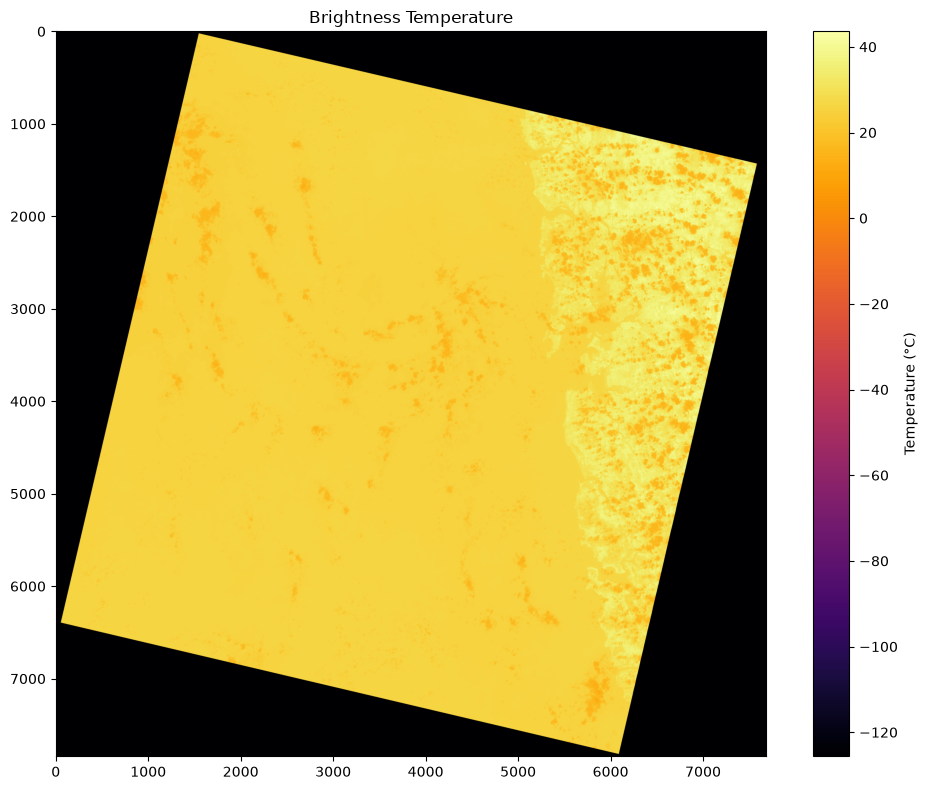

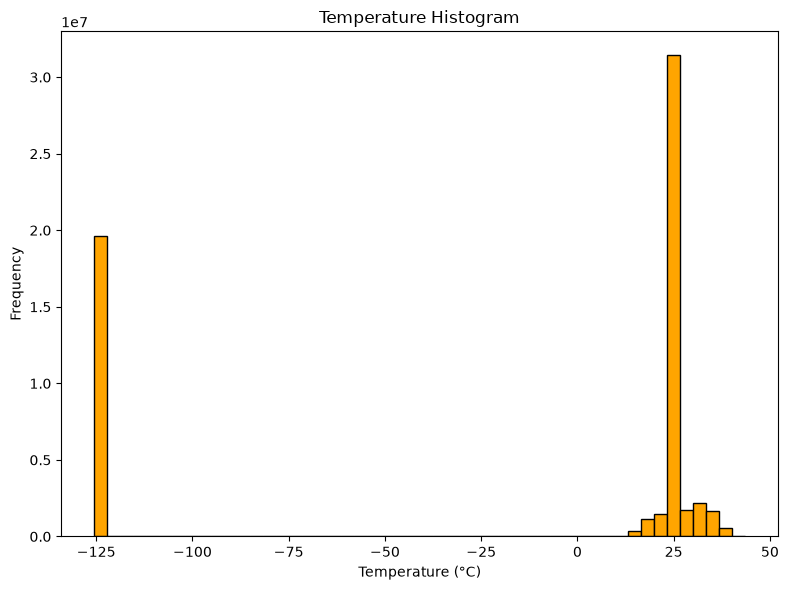

In [ ]:
from metadata import load_metadata
from thermal import dn_to_temperature
from visualization import plot_temperature
from visualization import plot_histogram
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

DATA = Path("../../data")
mtl = next(DATA.glob("*_MTL.txt"))
band10_path = next(DATA.glob("*_B10.TIF"))

metadata = load_metadata(mtl)

temp10 = dn_to_temperature(band10_path, metadata)

plot_temperature(temp10["temperature"])
plot_histogram(temp10["temperature"])


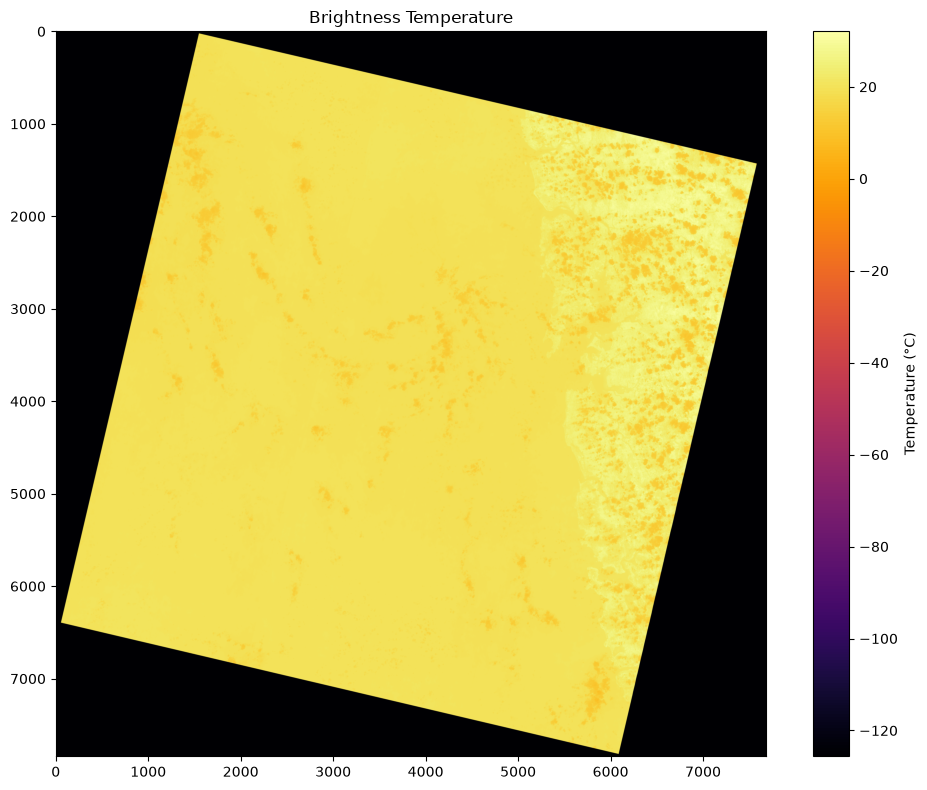

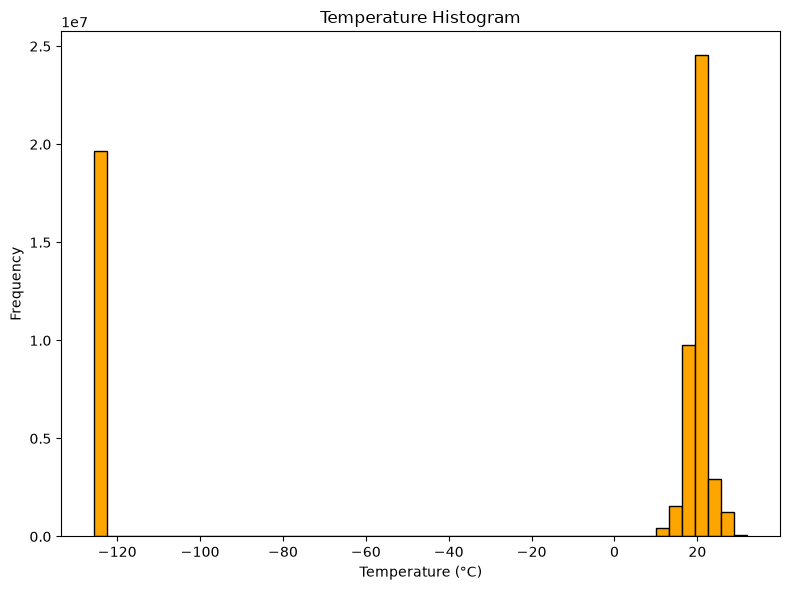

In [ ]:
band11_path = next(DATA.glob("*_B11.TIF"))
temp11 = dn_to_temperature(band11_path, metadata)

plot_temperature(temp11["temperature"])
plot_histogram(temp11["temperature"])


4.1983480655596885
4.165501200371797


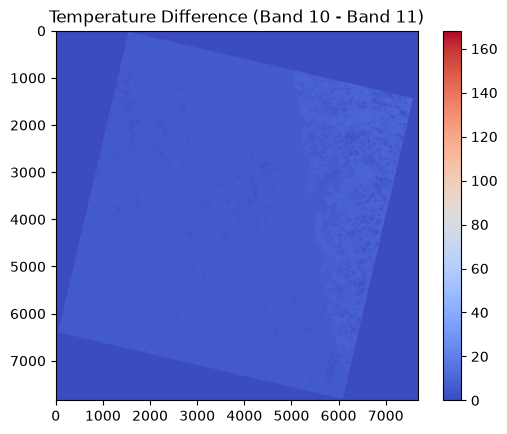

In [ ]:
difference = temp10["temperature"] - temp11["temperature"]

plt.imshow(difference, cmap="coolwarm")
plt.colorbar()
plt.title("Temperature Difference (Band 10 - Band 11)")

print(np.mean(difference))
print(np.std(difference))


## 12. Temperature Validation

The computed brightness temperatures were compared against the expected physical ranges documented for thermal infrared observations.

Typical observed brightness temperature ranges are:

| Surface | Expected Range |
|----------|----------------|
| Cold clouds | -70°C to -30°C |
| Water bodies | 15°C to 32°C |
| Vegetation | 15°C to 40°C |
| Urban surfaces | 25°C to 60°C |

The processed Landsat scene produced temperatures within physically reasonable limits, indicating that the DN -> Radiance -> Brightness Temperature conversion has been implemented correctly.

## 13. Conclusion

The implemented preprocessing pipeline successfully converts Landsat 8 Thermal Infrared Sensor (TIRS) Digital Numbers into physically meaningful Brightness Temperature values.

The workflow consists of:

1. Reading Landsat thermal GeoTIFF imagery.
2. Extracting calibration constants from the metadata file.
3. Computing Spectral Radiance.
4. Applying the inverse Planck equation to obtain Brightness Temperature.
5. Converting Kelvin to Celsius for visualization.
6. Validating the resulting temperature ranges.

This preprocessing pipeline forms the foundation for subsequent thermal analysis and machine learning workflows.